# Probability Distributions from Scratch

In this notebook, we'll explore the implementation and use of probability distributions from scratch. We'll study their properties, visualize them, and understand how they form the foundation of statistical thinking in machine learning.

## Learning Objectives
- Understand key probability distributions (Uniform, Normal, etc.)
- Implement probability distribution functions from scratch
- Visualize distributions and their properties
- Generate random samples from distributions
- Compare our implementations with NumPy/SciPy equivalents

In [14]:
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from scipy import stats

# Add the parent directory to the path so we can import our modules
sys.path.append('../..')
from phase0.statistics.probability_distributions import UniformDistribution, NormalDistribution

# Set the style for our plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Uniform Distribution

The uniform distribution represents equal probability over a range of values. If $X \sim \text{Uniform}(a, b)$, then the probability density function is:

$$f(x) = \begin{cases}
\frac{1}{b-a} & \text{for } a \leq x \leq b \\
0 & \text{otherwise}
\end{cases}$$

Let's explore our implementation of the uniform distribution.

In [15]:
# Create a uniform distribution on [0, 10]
uniform = UniformDistribution(0, 10)

# Print basic properties
print(f"Mean: {uniform.mean()}")
print(f"Variance: {uniform.variance()}")
print(f"Standard Deviation: {uniform.std_dev()}")

Mean: 5.0
Variance: 8.333333333333334
Standard Deviation: 2.886751345948129


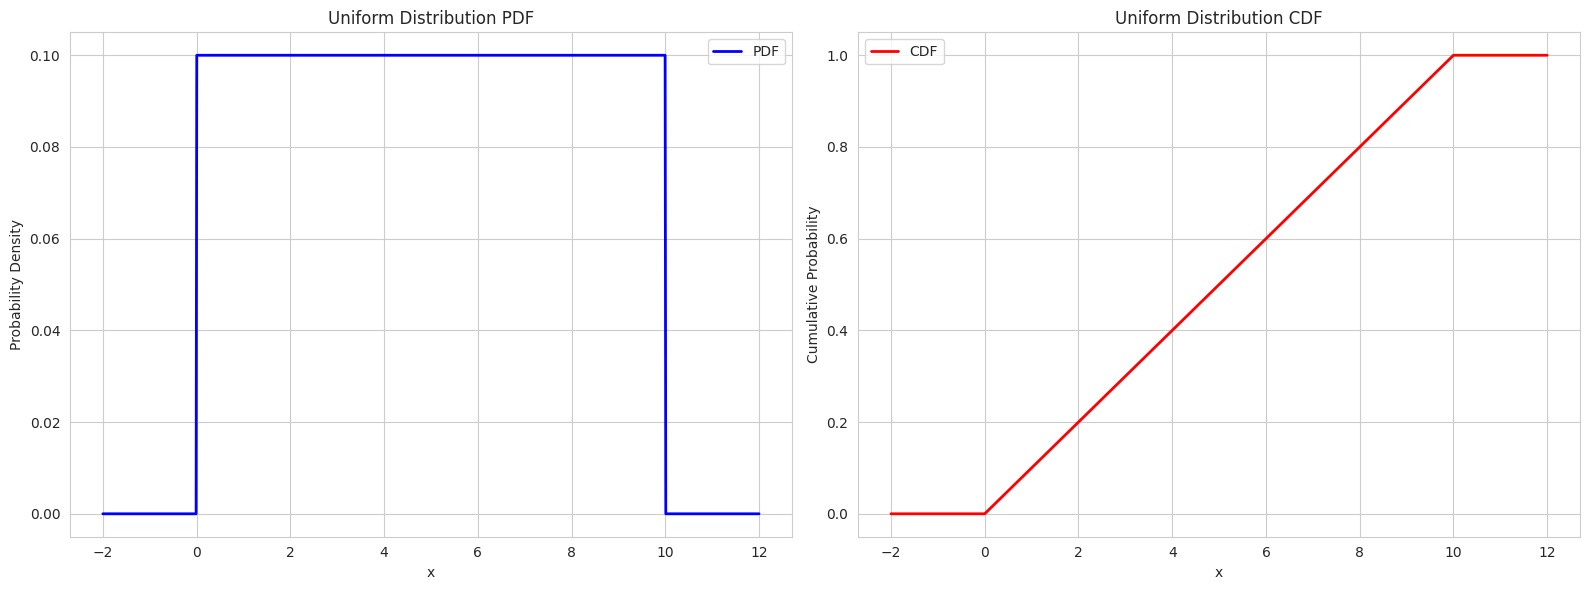

In [16]:
# Let's visualize the PDF and CDF
x = np.linspace(-2, 12, 1000)
pdf = [uniform.pdf(xi) for xi in x]
cdf = [uniform.cdf(xi) for xi in x]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(x, pdf, 'b-', lw=2, label='PDF')
ax1.set_title('Uniform Distribution PDF')
ax1.set_xlabel('x')
ax1.set_ylabel('Probability Density')
ax1.grid(True)
ax1.legend()

ax2.plot(x, cdf, 'r-', lw=2, label='CDF')
ax2.set_title('Uniform Distribution CDF')
ax2.set_xlabel('x')
ax2.set_ylabel('Cumulative Probability')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

### Generating Samples from the Uniform Distribution

Let's generate random samples from our uniform distribution and visualize them.

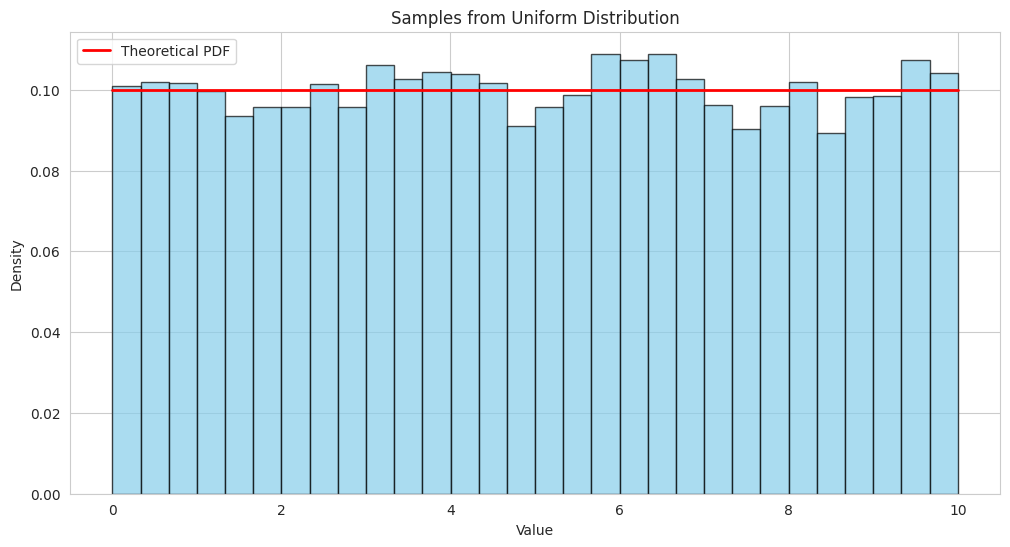

In [17]:
# Generate 10,000 samples
samples = [uniform.sample() for _ in range(10000)]

# Plot a histogram of the samples
plt.figure(figsize=(12, 6))
plt.hist(samples, bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black')

# Overlay the theoretical PDF for comparison
x = np.linspace(0, 10, 1000)
y = [uniform.pdf(xi) for xi in x]
plt.plot(x, y, 'r-', lw=2, label='Theoretical PDF')

plt.title('Samples from Uniform Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

### Comparing with NumPy/SciPy

Let's compare our implementation with the one provided by NumPy/SciPy.

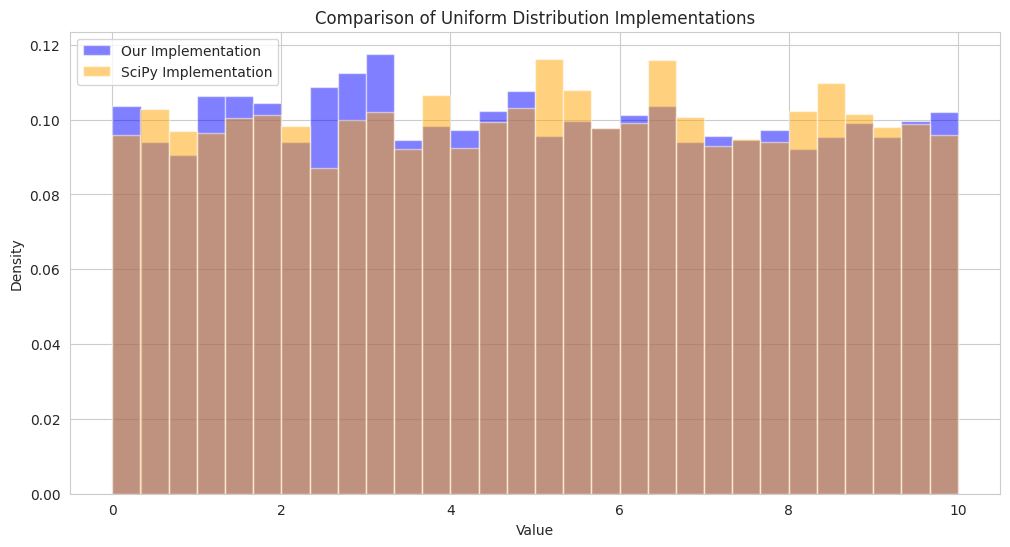

In [18]:
# Create scipy uniform distribution
scipy_uniform = stats.uniform(loc=0, scale=10)

# Generate samples from both distributions
our_samples = [uniform.sample() for _ in range(10000)]
scipy_samples = scipy_uniform.rvs(size=10000)

# Plot histograms for comparison
plt.figure(figsize=(12, 6))

plt.hist(our_samples, bins=30, alpha=0.5, label='Our Implementation', density=True, color='blue')
plt.hist(scipy_samples, bins=30, alpha=0.5, label='SciPy Implementation', density=True, color='orange')

plt.title('Comparison of Uniform Distribution Implementations')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

## 2. Normal Distribution

The normal (Gaussian) distribution is one of the most important probability distributions. If $X \sim \mathcal{N}(\mu, \sigma^2)$, then the probability density function is:

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}}e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$

Let's explore our implementation of the normal distribution.

In [19]:
# Create a normal distribution with mean 5 and standard deviation 2
normal = NormalDistribution(5, 2)

# Print basic properties
print(f"Mean: {normal.mean()}")
print(f"Variance: {normal.variance()}")
print(f"Standard Deviation: {normal.std_dev()}")

Mean: 5
Variance: 4
Standard Deviation: 2.0


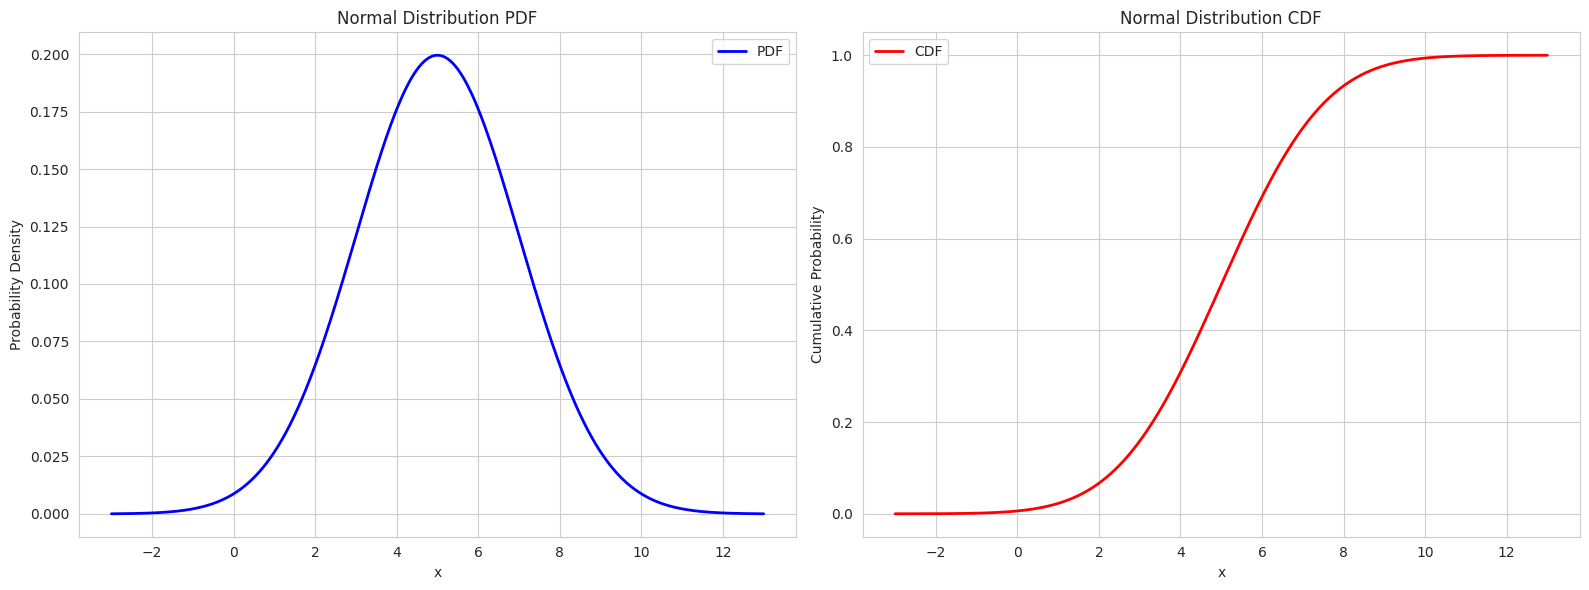

In [20]:
# Let's visualize the PDF and CDF
x = np.linspace(-3, 13, 1000)
pdf = [normal.pdf(xi) for xi in x]
cdf = [normal.cdf(xi) for xi in x]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(x, pdf, 'b-', lw=2, label='PDF')
ax1.set_title('Normal Distribution PDF')
ax1.set_xlabel('x')
ax1.set_ylabel('Probability Density')
ax1.grid(True)
ax1.legend()

ax2.plot(x, cdf, 'r-', lw=2, label='CDF')
ax2.set_title('Normal Distribution CDF')
ax2.set_xlabel('x')
ax2.set_ylabel('Cumulative Probability')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

### Generating Samples from the Normal Distribution

Let's generate random samples from our normal distribution and visualize them.

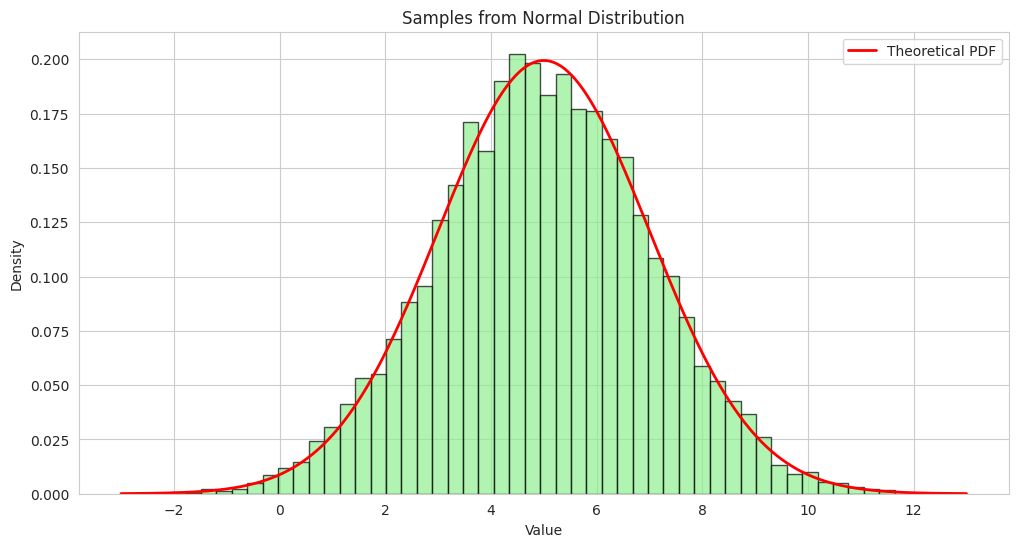

In [21]:
# Generate 10,000 samples
samples = [normal.sample() for _ in range(10000)]

# Plot a histogram of the samples
plt.figure(figsize=(12, 6))
plt.hist(samples, bins=50, density=True, alpha=0.7, color='lightgreen', edgecolor='black')

# Overlay the theoretical PDF for comparison
x = np.linspace(-3, 13, 1000)
y = [normal.pdf(xi) for xi in x]
plt.plot(x, y, 'r-', lw=2, label='Theoretical PDF')

plt.title('Samples from Normal Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

### Comparing with NumPy/SciPy

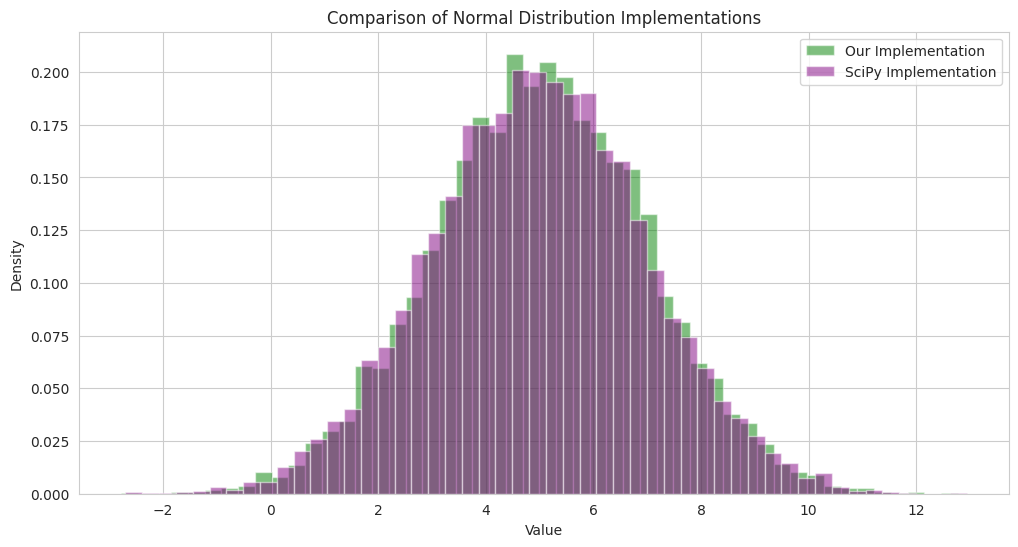

In [22]:
# Create scipy normal distribution
scipy_normal = stats.norm(loc=5, scale=2)

# Generate samples from both distributions
our_samples = [normal.sample() for _ in range(10000)]
scipy_samples = scipy_normal.rvs(size=10000)

# Plot histograms for comparison
plt.figure(figsize=(12, 6))

plt.hist(our_samples, bins=50, alpha=0.5, label='Our Implementation', density=True, color='green')
plt.hist(scipy_samples, bins=50, alpha=0.5, label='SciPy Implementation', density=True, color='purple')

plt.title('Comparison of Normal Distribution Implementations')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

## 3. Multiple Distributions Comparison

Let's visualize multiple distributions to better understand their differences.

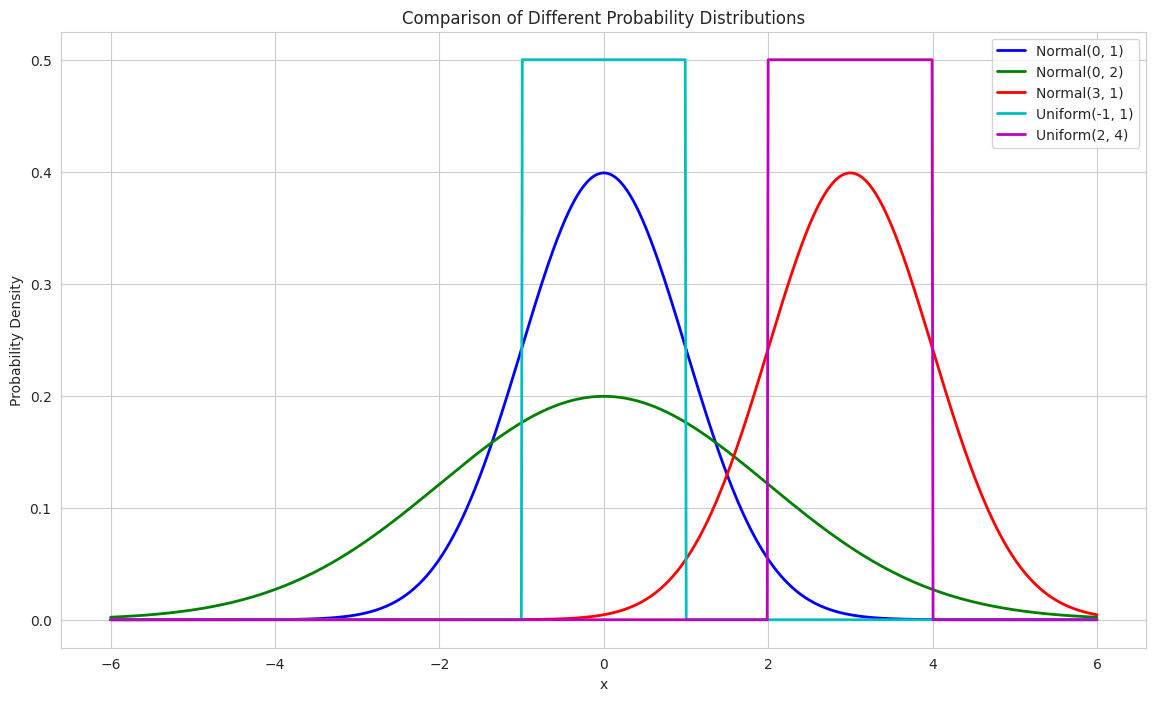

In [23]:
# Create several normal distributions with different parameters
norm_dist1 = NormalDistribution(0, 1)  # Standard normal
norm_dist2 = NormalDistribution(0, 2)  # Wider distribution
norm_dist3 = NormalDistribution(3, 1)  # Shifted distribution

# Create several uniform distributions
unif_dist1 = UniformDistribution(-1, 1)
unif_dist2 = UniformDistribution(2, 4)

# Setup plot points
x = np.linspace(-6, 6, 1000)

# Calculate PDF values
norm1_pdf = [norm_dist1.pdf(xi) for xi in x]
norm2_pdf = [norm_dist2.pdf(xi) for xi in x]
norm3_pdf = [norm_dist3.pdf(xi) for xi in x]
unif1_pdf = [unif_dist1.pdf(xi) for xi in x]
unif2_pdf = [unif_dist2.pdf(xi) for xi in x]

# Create the plot
plt.figure(figsize=(14, 8))

plt.plot(x, norm1_pdf, 'b-', lw=2, label='Normal(0, 1)')
plt.plot(x, norm2_pdf, 'g-', lw=2, label='Normal(0, 2)')
plt.plot(x, norm3_pdf, 'r-', lw=2, label='Normal(3, 1)')
plt.plot(x, unif1_pdf, 'c-', lw=2, label='Uniform(-1, 1)')
plt.plot(x, unif2_pdf, 'm-', lw=2, label='Uniform(2, 4)')

plt.title('Comparison of Different Probability Distributions')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()

## 4. Exercise: Implement a New Distribution

Now it's your turn! Let's implement a new distribution: the exponential distribution.

The exponential distribution has the PDF: $f(x) = \lambda e^{-\lambda x}$ for $x \geq 0$, where $\lambda > 0$ is the rate parameter.

Fill in the class below:

In [24]:
from phase0.statistics.probability_distributions import Distribution

class ExponentialDistribution(Distribution):
    """Exponential distribution."""
    
    def __init__(self, lam=1.0):
        """
        Create an exponential distribution with rate parameter lambda.
        
        Parameters:
        -----------
        lam : float
            Rate parameter of the distribution
        """
        if lam <= 0:
            raise ValueError("Rate parameter must be positive")
        
        self.lam = lam
    
    def sample(self):
        """
        Generate a random sample from the exponential distribution.
        Uses the inverse transform sampling method.
        """
        # TODO: Implement sampling from exponential distribution
        # Hint: use random.random() and the inverse CDF method
        u = random.random()
        return -math.log(1 - u) / self.lam
    
    def pdf(self, x):
        """Exponential probability density function at x."""
        # TODO: Implement PDF for exponential distribution
        if x < 0:
            return 0
        return self.lam * math.exp(-self.lam * x)
    
    def cdf(self, x):
        """Exponential cumulative distribution function at x."""
        # TODO: Implement CDF for exponential distribution
        if x < 0:
            return 0
        return 1 - math.exp(-self.lam * x)
    
    def mean(self):
        """Expected value of the exponential distribution."""
        # TODO: Implement mean for exponential distribution
        return 1 / self.lam
    
    def variance(self):
        """Variance of the exponential distribution."""
        # TODO: Implement variance for exponential distribution
        return 1 / (self.lam ** 2)

Mean: 2.0
Variance: 4.0
Standard Deviation: 2.0


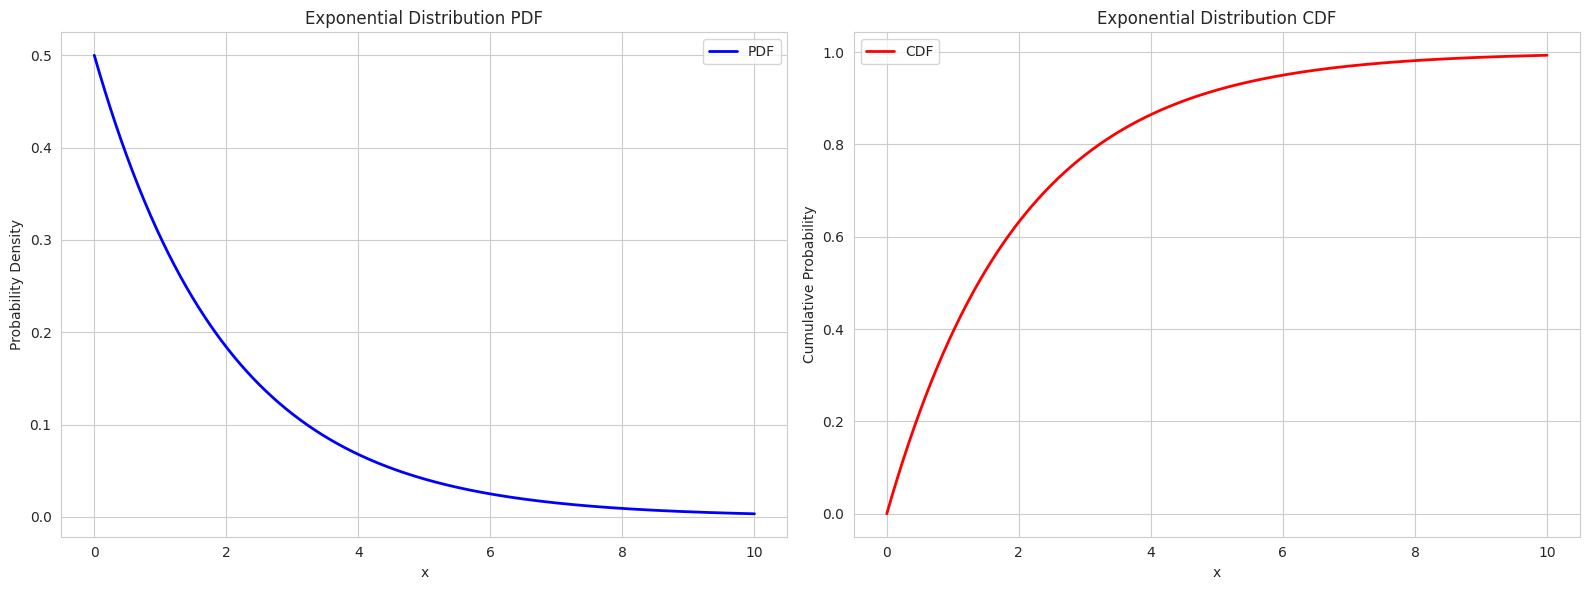

In [25]:
# Test your implementation
exp_dist = ExponentialDistribution(lam=0.5)

# Print basic properties
print(f"Mean: {exp_dist.mean()}")
print(f"Variance: {exp_dist.variance()}")
print(f"Standard Deviation: {exp_dist.std_dev()}")

# Visualize the PDF and CDF
x = np.linspace(0, 10, 1000)
pdf = [exp_dist.pdf(xi) for xi in x]
cdf = [exp_dist.cdf(xi) for xi in x]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(x, pdf, 'b-', lw=2, label='PDF')
ax1.set_title('Exponential Distribution PDF')
ax1.set_xlabel('x')
ax1.set_ylabel('Probability Density')
ax1.grid(True)
ax1.legend()

ax2.plot(x, cdf, 'r-', lw=2, label='CDF')
ax2.set_title('Exponential Distribution CDF')
ax2.set_xlabel('x')
ax2.set_ylabel('Cumulative Probability')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

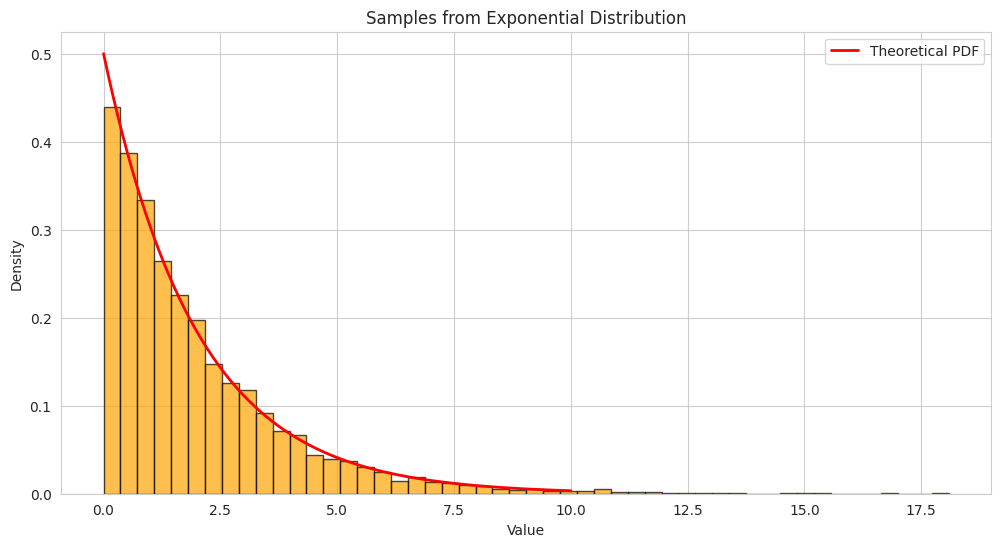

In [26]:
# Generate 10,000 samples and compare with theory
samples = [exp_dist.sample() for _ in range(10000)]

plt.figure(figsize=(12, 6))
plt.hist(samples, bins=50, density=True, alpha=0.7, color='orange', edgecolor='black')

# Overlay the theoretical PDF
x = np.linspace(0, 10, 1000)
y = [exp_dist.pdf(xi) for xi in x]
plt.plot(x, y, 'r-', lw=2, label='Theoretical PDF')

plt.title('Samples from Exponential Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

## 5. Central Limit Theorem Demonstration

The Central Limit Theorem (CLT) states that the sampling distribution of the mean of a sufficiently large number of independent random variables will be approximately normally distributed, regardless of the original distribution.

Let's demonstrate this with our distribution implementations.

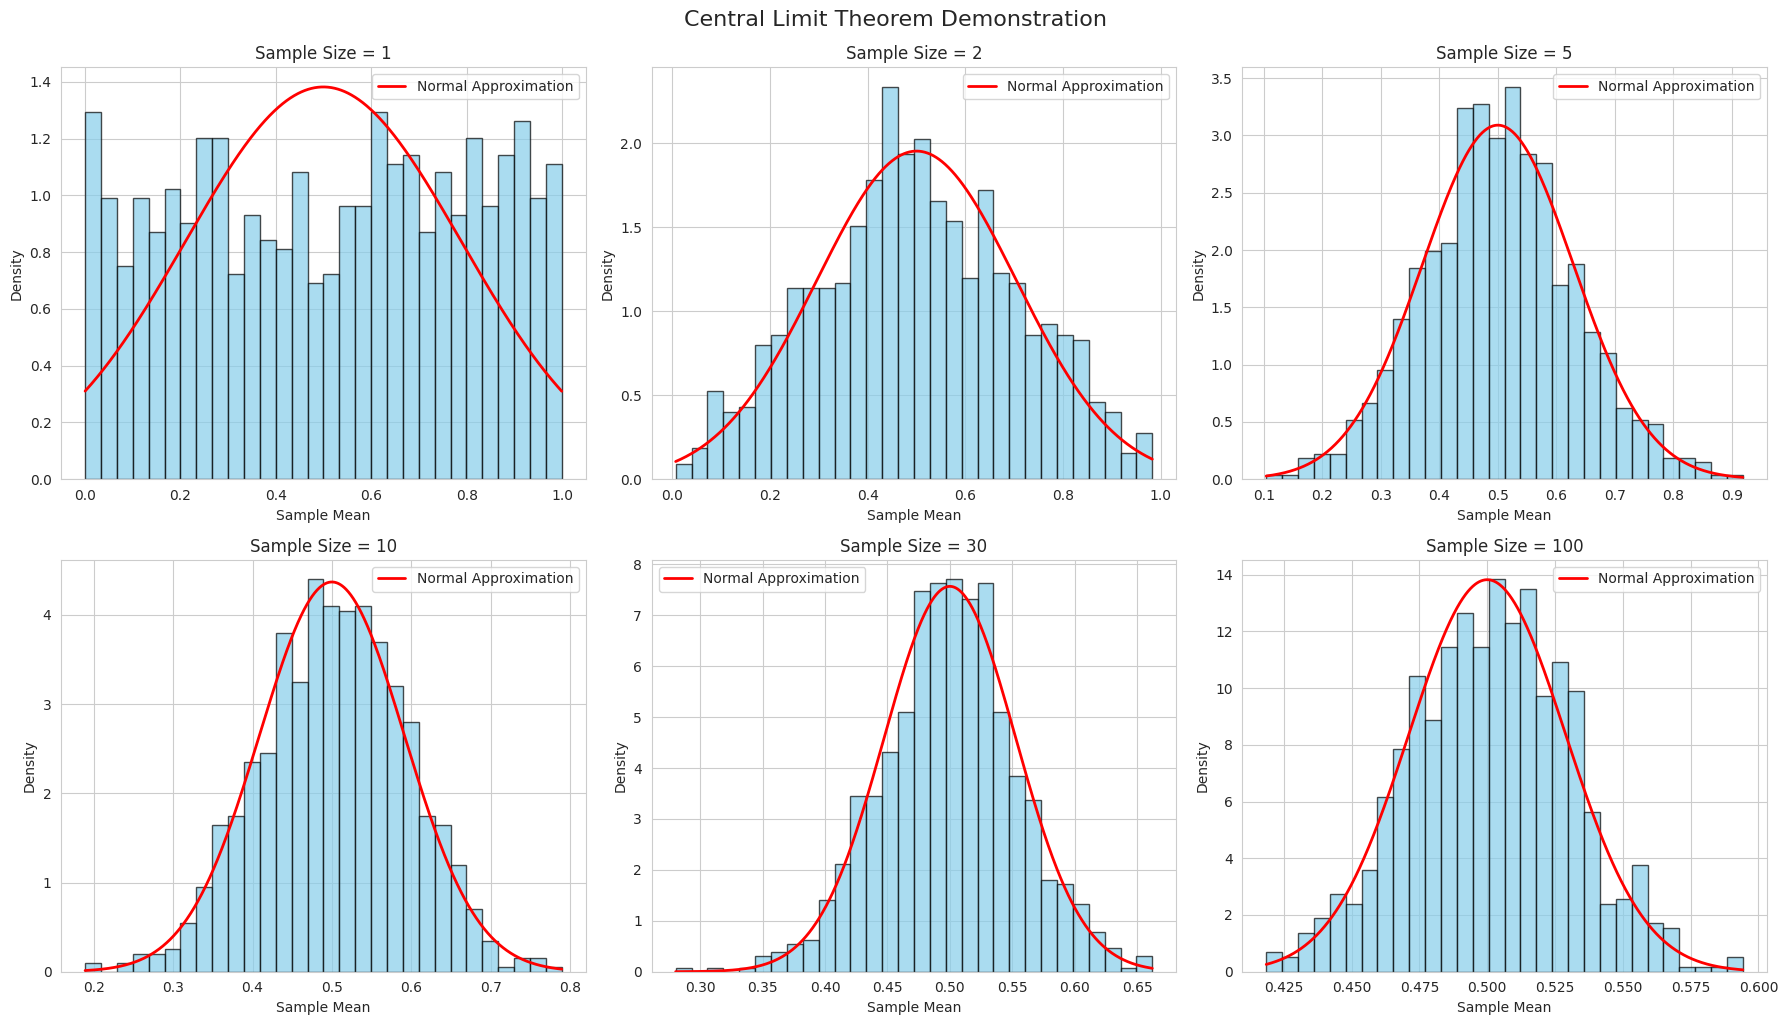

In [27]:
def sample_mean(dist, n_samples):
    """Calculate the mean of n_samples from the given distribution."""
    samples = [dist.sample() for _ in range(n_samples)]
    return sum(samples) / n_samples

# Create a uniform distribution
uniform_dist = UniformDistribution(0, 1)

# Sample means with different sample sizes
sample_sizes = [1, 2, 5, 10, 30, 100]
n_trials = 1000  # Number of times to compute the sample mean

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, n in enumerate(sample_sizes):
    # Compute multiple sample means
    means = [sample_mean(uniform_dist, n) for _ in range(n_trials)]
    
    # Plot histogram
    axes[i].hist(means, bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black')
    
    # Theoretical mean and standard deviation
    theoretical_mean = uniform_dist.mean()
    theoretical_std = math.sqrt(uniform_dist.variance() / n)
    
    # Overlay normal distribution with theoretical parameters
    x = np.linspace(min(means), max(means), 1000)
    normal = NormalDistribution(theoretical_mean, theoretical_std)
    y = [normal.pdf(xi) for xi in x]
    axes[i].plot(x, y, 'r-', lw=2, label='Normal Approximation')
    
    axes[i].set_title(f'Sample Size = {n}')
    axes[i].set_xlabel('Sample Mean')
    axes[i].set_ylabel('Density')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.suptitle('Central Limit Theorem Demonstration', fontsize=16, y=1.02)
plt.show()

## Conclusion

In this notebook, we've explored the implementation of probability distributions from scratch. We've learned:

1. How to define and implement probability distributions
2. The properties of uniform and normal distributions
3. How to generate random samples from these distributions
4. The Central Limit Theorem through practical demonstration

In the next notebook, we'll explore statistical inference techniques, including likelihood estimation and hypothesis testing.